# Polynomial Regression

## Problem Statement
- Predict salary based on employee position

### Import required packages

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the data

In [6]:
df = pd.read_csv('./Position_Salaries.csv')

### Exploratry data analysis

In [7]:
# Get the general infromation
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [8]:
# Since the position and label have similar information let's drop position
df.drop('Position', axis=1, inplace=True)

In [9]:
# Correlation analysis
df.corr()

,Level,Salary
Level,1.000000,0.817949
Salary,0.817949,1.000000


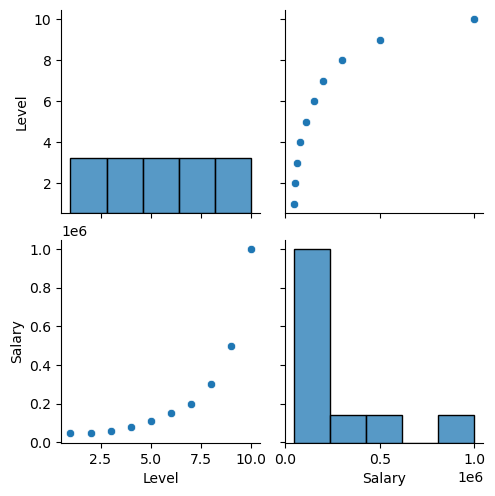

In [10]:
# Visualize the relationship
sns.pairplot(df)

### Split the data

In [11]:
# Split data into x and y
x = df.drop('Salary', axis=1)
y = df['Salary']

### Prepare the dataset

In [20]:
from sklearn.preprocessing import PolynomialFeatures

# Create an object of polynomial features
polynomial_features = PolynomialFeatures(degree = 4)

# Fit and transform the data
x_new = polynomial_features.fit_transform(x)

In [21]:
x_new

array([[1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00],
       [1.000e+00, 2.000e+00, 4.000e+00, 8.000e+00, 1.600e+01],
       [1.000e+00, 3.000e+00, 9.000e+00, 2.700e+01, 8.100e+01],
       [1.000e+00, 4.000e+00, 1.600e+01, 6.400e+01, 2.560e+02],
       [1.000e+00, 5.000e+00, 2.500e+01, 1.250e+02, 6.250e+02],
       [1.000e+00, 6.000e+00, 3.600e+01, 2.160e+02, 1.296e+03],
       [1.000e+00, 7.000e+00, 4.900e+01, 3.430e+02, 2.401e+03],
       [1.000e+00, 8.000e+00, 6.400e+01, 5.120e+02, 4.096e+03],
       [1.000e+00, 9.000e+00, 8.100e+01, 7.290e+02, 6.561e+03],
       [1.000e+00, 1.000e+01, 1.000e+02, 1.000e+03, 1.000e+04]])

### Train the model

In [22]:
from sklearn.linear_model import LinearRegression

# Create a model
model = LinearRegression()

# Train the model
model.fit(x_new, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Evaluate the model

In [23]:
from sklearn.metrics import r2_score

# Predict the values for x
y_pred = model.predict(x_new)

# Get r2 Score
r2 = r2_score(y, y_pred)
print(f"R2 Score is {r2:.2f}")

R2 Score is 1.00


### Result visulization

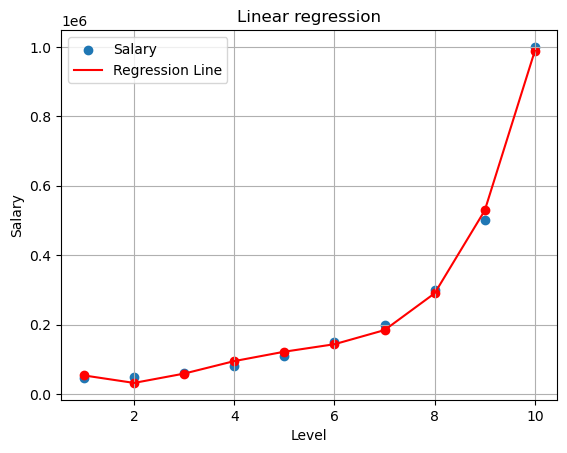

In [24]:
# Plot the data
plt.scatter(x['Level'], y, label="Salary")

#Plot the regression line
plt.scatter(x['Level'], y_pred, color="red")
plt.plot(x['Level'], y_pred, color="red", label="Regression Line")

plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Linear regression")
plt.grid()
plt.legend()